In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Install if needed
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout,
    BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('✅ Libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

2026-03-09 13:12:10.095683: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773061930.333725      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773061930.398587      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773061930.897311      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773061930.897369      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773061930.897372      55 computation_placer.cc:177] computation placer alr

✅ Libraries imported successfully!
TensorFlow version: 2.19.0


In [3]:
# ── Load all feature files ──────────────────────────────────────────
humidity     = pd.read_csv('/kaggle/input/datasets/selfishgene/historical-hourly-weather-data/humidity.csv',             index_col='datetime', parse_dates=True)
pressure     = pd.read_csv('/kaggle/input/datasets/selfishgene/historical-hourly-weather-data/pressure.csv',             index_col='datetime', parse_dates=True)
temperature  = pd.read_csv('/kaggle/input/datasets/selfishgene/historical-hourly-weather-data/temperature.csv',          index_col='datetime', parse_dates=True)
wind_speed   = pd.read_csv('/kaggle/input/datasets/selfishgene/historical-hourly-weather-data/wind_speed.csv',           index_col='datetime', parse_dates=True)
wind_dir     = pd.read_csv('/kaggle/input/datasets/selfishgene/historical-hourly-weather-data/wind_direction.csv',       index_col='datetime', parse_dates=True)
weather_desc = pd.read_csv('/kaggle/input/datasets/selfishgene/historical-hourly-weather-data/weather_description.csv',  index_col='datetime', parse_dates=True)

# ── Choose one city (e.g. Vancouver — high rainfall) ────────────────
CITY = 'Vancouver'

df = pd.DataFrame({
    'humidity':    humidity[CITY],
    'pressure':    pressure[CITY],
    'temperature': temperature[CITY],
    'wind_speed':  wind_speed[CITY],
    'wind_dir':    wind_dir[CITY],
    'description': weather_desc[CITY]
})

print(f'✅ Dataset loaded for city: {CITY}')
print(f'Shape: {df.shape}')
df.head()

✅ Dataset loaded for city: Vancouver
Shape: (45253, 6)


,humidity,pressure,temperature,wind_speed,wind_dir,description
datetime,,,,,,
2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2012-10-01 13:00:00,76.0,NaN,284.630000,0.0,0.0,mist
2012-10-01 14:00:00,76.0,NaN,284.629041,0.0,6.0,broken clouds
2012-10-01 15:00:00,76.0,NaN,284.626998,0.0,20.0,broken clouds
2012-10-01 16:00:00,77.0,NaN,284.624955,0.0,34.0,broken clouds


In [4]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45253 entries, 2012-10-01 12:00:00 to 2017-11-30 00:00:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   humidity     43427 non-null  float64
 1   pressure     41019 non-null  float64
 2   temperature  44458 non-null  float64
 3   wind_speed   44458 non-null  float64
 4   wind_dir     44458 non-null  float64
 5   description  44460 non-null  object 
dtypes: float64(5), object(1)
memory usage: 2.4+ MB
None

=== Missing Values ===
humidity       1826
pressure       4234
temperature     795
wind_speed      795
wind_dir        795
description     793
dtype: int64

=== Basic Statistics ===


,humidity,pressure,temperature,wind_speed,wind_dir
count,43427.000000,41019.000000,44458.000000,44458.000000,44458.000000
mean,81.895480,1018.130915,283.862654,2.432746,159.892978
std,14.522221,15.792425,6.640131,2.004636,98.163221
min,12.000000,807.000000,245.150000,0.000000,0.000000
25%,73.000000,1012.000000,279.160000,1.000000,80.000000
50%,86.000000,1017.000000,283.450000,2.000000,140.000000
75%,93.000000,1022.000000,288.600785,4.000000,236.000000
max,100.000000,1100.000000,307.000000,25.000000,360.000000


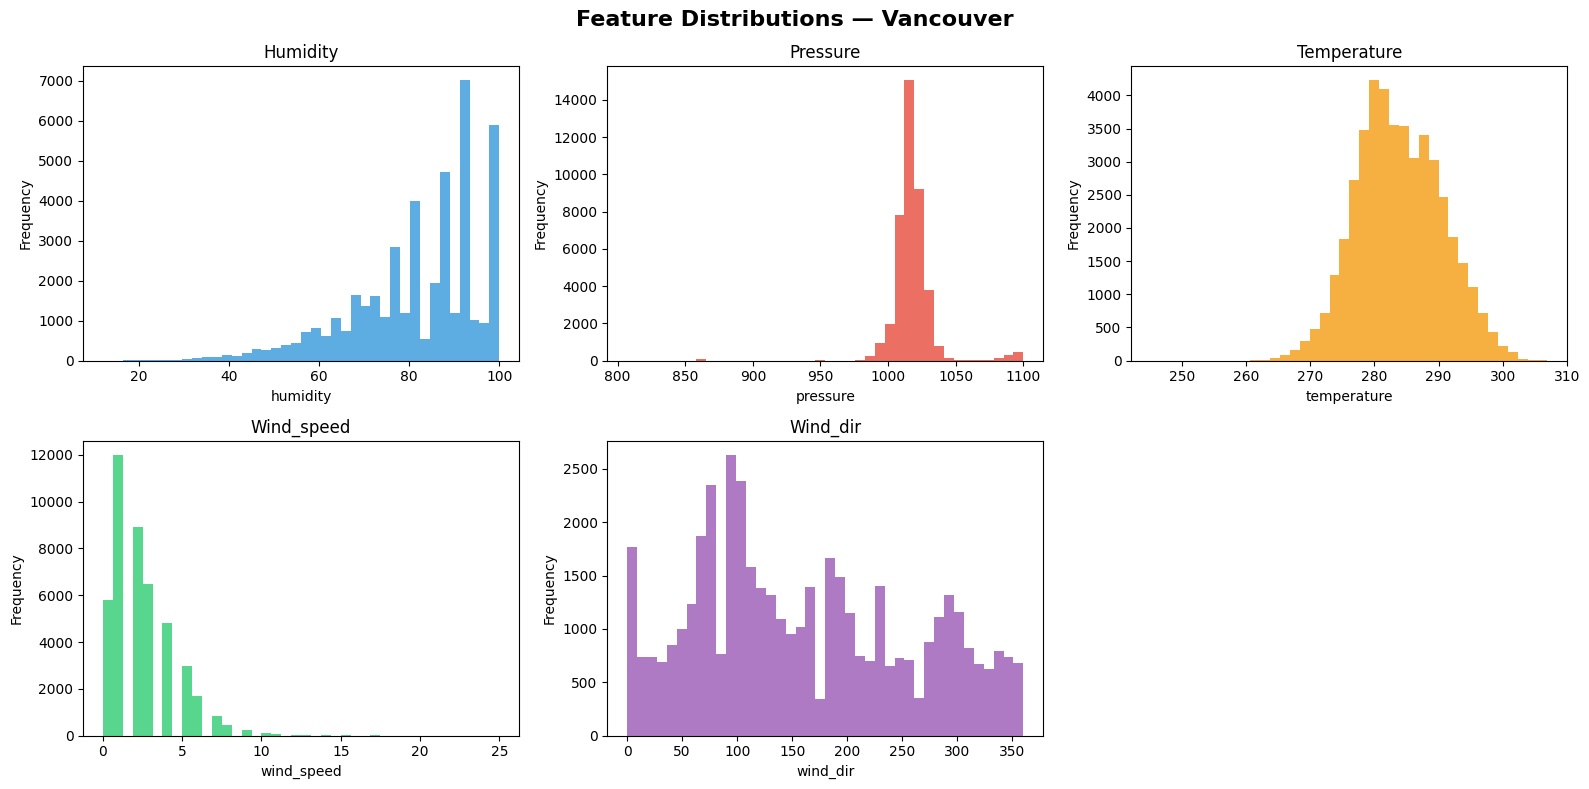

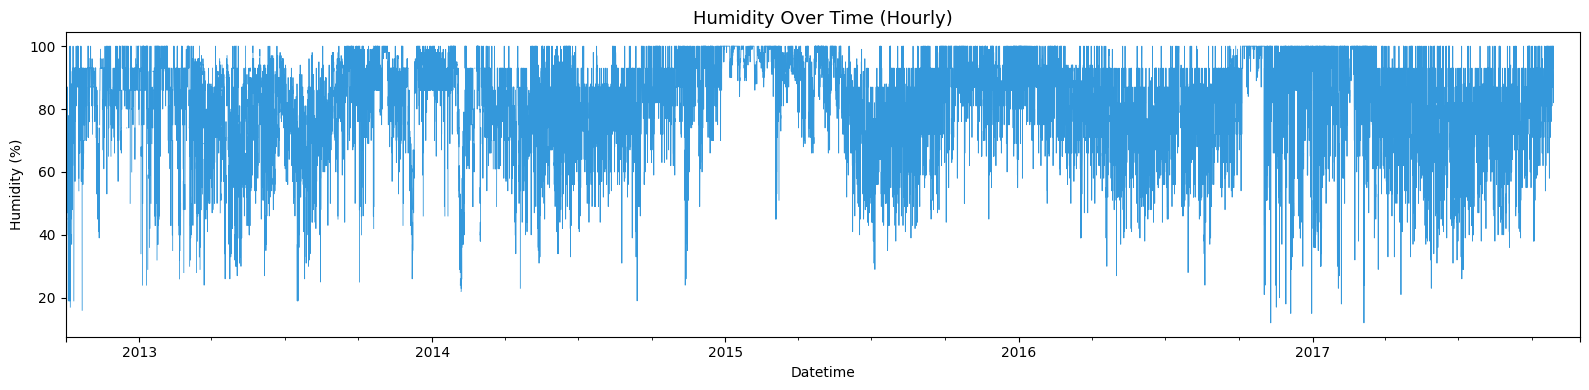

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f'Feature Distributions — {CITY}', fontsize=16, fontweight='bold')

features = ['humidity', 'pressure', 'temperature', 'wind_speed', 'wind_dir']
colors   = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6']

for i, (feat, color) in enumerate(zip(features, colors)):
    ax = axes[i // 3][i % 3]
    df[feat].dropna().plot(kind='hist', bins=40, color=color, ax=ax, alpha=0.8)
    ax.set_title(feat.capitalize())
    ax.set_xlabel(feat)

axes[1][2].axis('off')
plt.tight_layout()
plt.show()

# Time series plot
fig, ax = plt.subplots(figsize=(16, 4))
df['humidity'].plot(ax=ax, color='#3498db', linewidth=0.6)
ax.set_title('Humidity Over Time (Hourly)', fontsize=13)
ax.set_xlabel('Datetime')
ax.set_ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

=== Class Distribution ===
No Rain (0): 30,389 (67.2%)
Rain    (1): 14,071 (31.1%)


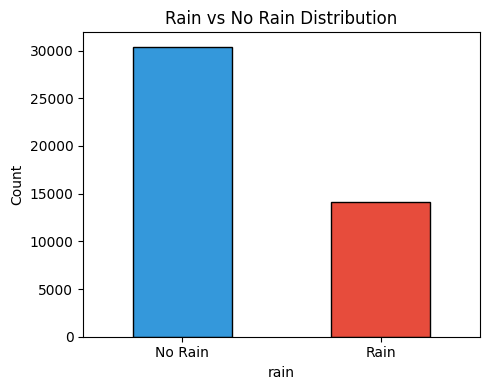

In [7]:
# ── Rain keywords ────────────────────────────────────────────────────
RAIN_KEYWORDS = [
    'rain', 'drizzle', 'shower', 'thunderstorm',
    'sleet', 'mist', 'freezing rain', 'heavy intensity rain',
    'light rain', 'moderate rain', 'very heavy rain'
]

def is_rain(desc):
    if pd.isna(desc):
        return np.nan
    return int(any(kw in str(desc).lower() for kw in RAIN_KEYWORDS))

df['rain'] = df['description'].apply(is_rain)

# Class balance
counts = df['rain'].value_counts()
print('=== Class Distribution ===')
print(f"No Rain (0): {counts.get(0, 0):,} ({counts.get(0,0)/len(df)*100:.1f}%)")
print(f"Rain    (1): {counts.get(1, 0):,} ({counts.get(1,0)/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', color=['#3498db', '#e74c3c'], ax=ax, edgecolor='black')
ax.set_xticklabels(['No Rain', 'Rain'], rotation=0)
ax.set_title('Rain vs No Rain Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [8]:
FEATURE_COLS = ['humidity', 'pressure', 'temperature', 'wind_speed', 'wind_dir']

# ── Drop rows with missing values ────────────────────────────────────
df_clean = df[FEATURE_COLS + ['rain']].dropna().copy()

# ── Add time-based features ──────────────────────────────────────────
df_clean['hour']       = df_clean.index.hour
df_clean['month']      = df_clean.index.month
df_clean['hour_sin']   = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos']   = np.cos(2 * np.pi * df_clean['hour'] / 24)
df_clean['month_sin']  = np.sin(2 * np.pi * df_clean['month'] / 12)
df_clean['month_cos']  = np.cos(2 * np.pi * df_clean['month'] / 12)

# ── Lag features (past 3, 6, 12, 24 hours of humidity & pressure) ────
for lag in [3, 6, 12, 24]:
    df_clean[f'humidity_lag{lag}']  = df_clean['humidity'].shift(lag)
    df_clean[f'pressure_lag{lag}']  = df_clean['pressure'].shift(lag)

# ── Rolling averages ─────────────────────────────────────────────────
df_clean['humidity_roll6']  = df_clean['humidity'].rolling(6).mean()
df_clean['pressure_roll6']  = df_clean['pressure'].rolling(6).mean()
df_clean['windspeed_roll6'] = df_clean['wind_speed'].rolling(6).mean()

df_clean.dropna(inplace=True)

print(f'✅ Cleaned dataset shape: {df_clean.shape}')
print(f'Features created: {df_clean.shape[1] - 1}')

✅ Cleaned dataset shape: (40600, 23)
Features created: 22


In [9]:
from sklearn.utils import resample

# Separate classes
df_majority = df_clean[df_clean['rain'] == 0]
df_minority = df_clean[df_clean['rain'] == 1]

# Upsample minority class
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled]).sort_index()

print(f'✅ Balanced dataset shape: {df_balanced.shape}')
print(df_balanced['rain'].value_counts())

# ── Separate features & labels ────────────────────────────────────────
ALL_FEATURES = [c for c in df_balanced.columns if c != 'rain']
X = df_balanced[ALL_FEATURES].values
y = df_balanced['rain'].values

# ── Min-Max Normalize ─────────────────────────────────────────────────
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nFeature matrix shape: {X_scaled.shape}')

✅ Balanced dataset shape: (55954, 23)
rain
0.0    27977
1.0    27977
Name: count, dtype: int64

Feature matrix shape: (55954, 22)


In [10]:
LOOKBACK = 24  # Use past 24 hours to predict next hour

def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y, LOOKBACK)

print(f'✅ Sequence shape: {X_seq.shape}')   # (samples, timesteps, features)
print(f'Label shape    : {y_seq.shape}')

✅ Sequence shape: (55930, 24, 22)
Label shape    : (55930,)


In [11]:
# Time-ordered split (no shuffling — preserves temporal structure)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST         = remaining 0.15

n      = len(X_seq)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

X_train = X_seq[:n_train]
y_train = y_seq[:n_train]

X_val   = X_seq[n_train : n_train + n_val]
y_val   = y_seq[n_train : n_train + n_val]

X_test  = X_seq[n_train + n_val:]
y_test  = y_seq[n_train + n_val:]

print(f'✅ Train : {X_train.shape}  Labels: {y_train.shape}')
print(f'   Val   : {X_val.shape}  Labels: {y_val.shape}')
print(f'   Test  : {X_test.shape}  Labels: {y_test.shape}')

✅ Train : (39151, 24, 22)  Labels: (39151,)
   Val   : (8389, 24, 22)  Labels: (8389,)
   Test  : (8390, 24, 22)  Labels: (8390,)


In [12]:
n_timesteps = X_train.shape[1]   # 24
n_features  = X_train.shape[2]   # number of feature columns

def build_bilstm(n_timesteps, n_features):
    inputs = Input(shape=(n_timesteps, n_features))

    # ── BiLSTM Block 1 ──────────────────────────────────────
    x = Bidirectional(LSTM(128, return_sequences=True,
                           dropout=0.2, recurrent_dropout=0.1))(inputs)
    x = BatchNormalization()(x)

    # ── BiLSTM Block 2 ──────────────────────────────────────
    x = Bidirectional(LSTM(64, return_sequences=True,
                           dropout=0.2, recurrent_dropout=0.1))(x)
    x = BatchNormalization()(x)

    # ── BiLSTM Block 3 ──────────────────────────────────────
    x = Bidirectional(LSTM(32, dropout=0.2))(x)
    x = BatchNormalization()(x)

    # ── Dense Classifier ────────────────────────────────────
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model

model = build_bilstm(n_timesteps, n_features)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

2026-03-09 13:18:50.682978: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 22)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       154,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 24, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 368,257 (1.40 MB)

 Trainable params: 367,361 (1.40 MB)

 Non-trainable params: 896 (3.50 KB)

In [13]:
# ── Callbacks ────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_auc', mode='max',
        patience=10, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        'best_bilstm_rainfall.h5', monitor='val_auc',
        mode='max', save_best_only=True, verbose=1
    )
]

# ── Train ─────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print('✅ Training complete!')

Epoch 1/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5590 - auc: 0.5832 - loss: 0.6922 - precision: 0.5345 - recall: 0.5089
Epoch 1: val_auc improved from -inf to 0.72976, saving model to best_bilstm_rainfall.h5


612/612 ━━━━━━━━━━━━━━━━━━━━ 101s 136ms/step - accuracy: 0.5591 - auc: 0.5833 - loss: 0.6922 - precision: 0.5345 - recall: 0.5090 - val_accuracy: 0.6581 - val_auc: 0.7298 - val_loss: 0.6244 - val_precision: 0.7551 - val_recall: 0.6121 - learning_rate: 0.0010
Epoch 2/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6498 - auc: 0.6974 - loss: 0.6321 - precision: 0.6294 - recall: 0.6339
Epoch 2: val_auc improved from 0.72976 to 0.75541, saving model to best_bilstm_rainfall.h5


612/612 ━━━━━━━━━━━━━━━━━━━━ 81s 133ms/step - accuracy: 0.6498 - auc: 0.6974 - loss: 0.6321 - precision: 0.6294 - recall: 0.6340 - val_accuracy: 0.6431 - val_auc: 0.7554 - val_loss: 0.6589 - val_precision: 0.7923 - val_recall: 0.5257 - learning_rate: 0.0010
Epoch 3/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7058 - auc: 0.7683 - loss: 0.5779 - precision: 0.6903 - recall: 0.6873
Epoch 3: val_auc improved from 0.75541 to 0.79858, saving model to best_bilstm_rainfall.h5


612/612 ━━━━━━━━━━━━━━━━━━━━ 82s 133ms/step - accuracy: 0.7059 - auc: 0.7683 - loss: 0.5778 - precision: 0.6904 - recall: 0.6874 - val_accuracy: 0.7512 - val_auc: 0.7986 - val_loss: 0.5383 - val_precision: 0.7805 - val_recall: 0.7976 - learning_rate: 0.0010
Epoch 4/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7482 - auc: 0.8106 - loss: 0.5335 - precision: 0.7281 - recall: 0.7481
Epoch 4: val_auc improved from 0.79858 to 0.80582, saving model to best_bilstm_rainfall.h5


612/612 ━━━━━━━━━━━━━━━━━━━━ 81s 132ms/step - accuracy: 0.7482 - auc: 0.8106 - loss: 0.5335 - precision: 0.7281 - recall: 0.7481 - val_accuracy: 0.7522 - val_auc: 0.8058 - val_loss: 0.5395 - val_precision: 0.8002 - val_recall: 0.7663 - learning_rate: 0.0010
Epoch 5/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7669 - auc: 0.8271 - loss: 0.5125 - precision: 0.7474 - recall: 0.7674
Epoch 5: val_auc improved from 0.80582 to 0.83636, saving model to best_bilstm_rainfall.h5


...

612/612 ━━━━━━━━━━━━━━━━━━━━ 80s 131ms/step - accuracy: 0.8323 - auc: 0.8907 - loss: 0.4106 - precision: 0.8056 - recall: 0.8517 - val_accuracy: 0.8350 - val_auc: 0.8868 - val_loss: 0.4110 - val_precision: 0.8381 - val_recall: 0.8888 - learning_rate: 0.0010
Epoch 30/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8323 - auc: 0.8908 - loss: 0.4106 - precision: 0.8037 - recall: 0.8550
Epoch 30: val_auc improved from 0.88678 to 0.88837, saving model to best_bilstm_rainfall.h5


612/612 ━━━━━━━━━━━━━━━━━━━━ 80s 131ms/step - accuracy: 0.8323 - auc: 0.8908 - loss: 0.4106 - precision: 0.8037 - recall: 0.8550 - val_accuracy: 0.8376 - val_auc: 0.8884 - val_loss: 0.4076 - val_precision: 0.8395 - val_recall: 0.8920 - learning_rate: 0.0010
Epoch 31/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8318 - auc: 0.8921 - loss: 0.4087 - precision: 0.8050 - recall: 0.8511
Epoch 31: val_auc improved from 0.88837 to 0.88866, saving model to best_bilstm_rainfall.h5


612/612 ━━━━━━━━━━━━━━━━━━━━ 80s 131ms/step - accuracy: 0.8318 - auc: 0.8921 - loss: 0.4087 - precision: 0.8050 - recall: 0.8511 - val_accuracy: 0.8361 - val_auc: 0.8887 - val_loss: 0.4084 - val_precision: 0.8436 - val_recall: 0.8824 - learning_rate: 0.0010
Epoch 32/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8348 - auc: 0.8905 - loss: 0.4097 - precision: 0.8072 - recall: 0.8558
Epoch 32: val_auc improved from 0.88866 to 0.88963, saving model to best_bilstm_rainfall.h5


612/612 ━━━━━━━━━━━━━━━━━━━━ 81s 132ms/step - accuracy: 0.8348 - auc: 0.8905 - loss: 0.4097 - precision: 0.8072 - recall: 0.8558 - val_accuracy: 0.8385 - val_auc: 0.8896 - val_loss: 0.4069 - val_precision: 0.8432 - val_recall: 0.8882 - learning_rate: 0.0010
Epoch 33/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8342 - auc: 0.8916 - loss: 0.4080 - precision: 0.8059 - recall: 0.8563
Epoch 33: val_auc improved from 0.88963 to 0.89086, saving model to best_bilstm_rainfall.h5


612/612 ━━━━━━━━━━━━━━━━━━━━ 81s 132ms/step - accuracy: 0.8342 - auc: 0.8916 - loss: 0.4080 - precision: 0.8059 - recall: 0.8563 - val_accuracy: 0.8375 - val_auc: 0.8909 - val_loss: 0.4052 - val_precision: 0.8413 - val_recall: 0.8890 - learning_rate: 0.0010
Epoch 34/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8352 - auc: 0.8925 - loss: 0.4072 - precision: 0.8088 - recall: 0.8541
Epoch 34: val_auc did not improve from 0.89086
612/612 ━━━━━━━━━━━━━━━━━━━━ 81s 132ms/step - accuracy: 0.8352 - auc: 0.8925 - loss: 0.4072 - precision: 0.8088 - recall: 0.8541 - val_accuracy: 0.8378 - val_auc: 0.8875 - val_loss: 0.4103 - val_precision: 0.8435 - val_recall: 0.8861 - learning_rate: 0.0010
Epoch 35/60
612/612 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8337 - auc: 0.8936 - loss: 0.4055 - precision: 0.8066 - recall: 0.8538
Epoch 35: val_auc did not improve from 0.89086
612/612 ━━━━━━━━━━━━━━━━━━━━ 82s 133ms/step - accuracy: 0.8337 - auc: 0.8936 - loss: 0.4055 - precision: 0.806

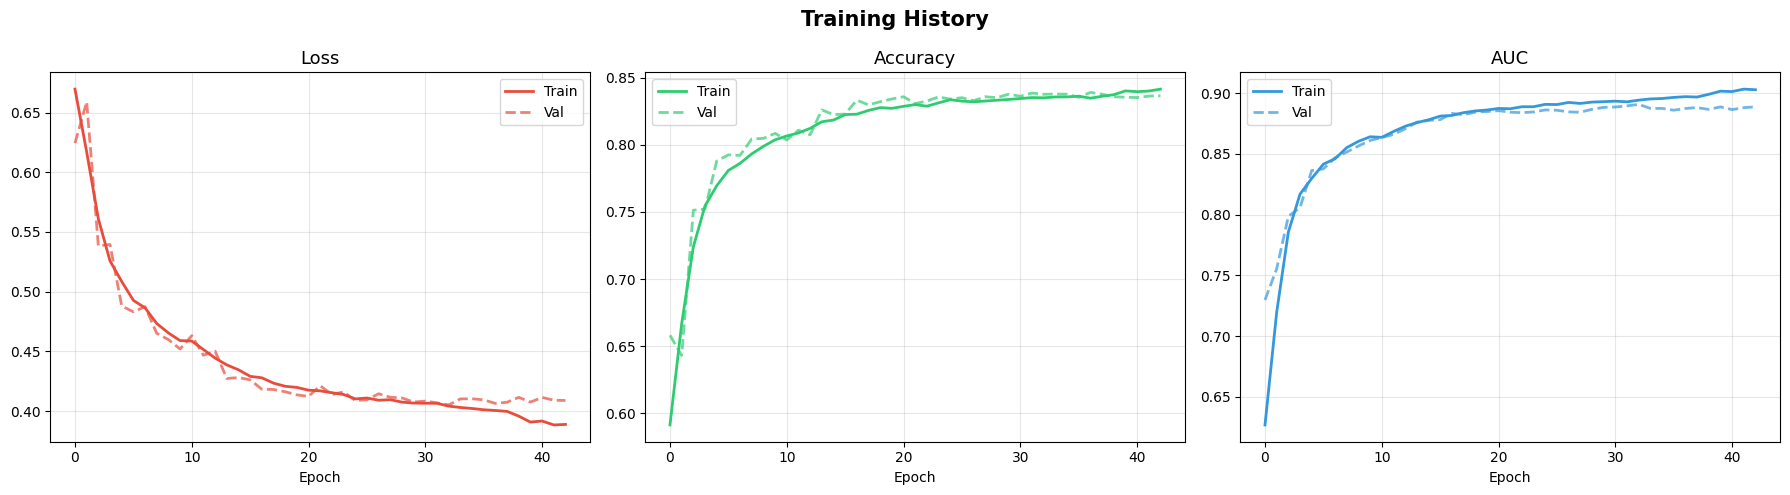

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=15, fontweight='bold')

metrics_pairs = [
    ('loss',     'val_loss',     'Loss',     '#e74c3c'),
    ('accuracy', 'val_accuracy', 'Accuracy', '#2ecc71'),
    ('auc',      'val_auc',      'AUC',      '#3498db'),
]

for ax, (train_m, val_m, title, color) in zip(axes, metrics_pairs):
    ax.plot(history.history[train_m], color=color, label='Train', linewidth=2)
    ax.plot(history.history[val_m],   color=color, label='Val',
            linestyle='--', linewidth=2, alpha=0.7)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# ── Predict ───────────────────────────────────────────────────────────
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────
acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('=' * 45)
print('          📊 TEST SET RESULTS')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 45)
print('\n🔍 Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))

          📊 TEST SET RESULTS
  Accuracy  : 0.8334  (83.34%)
  F1-Score  : 0.8500
  ROC-AUC   : 0.8830

🔍 Classification Report:
              precision    recall  f1-score   support

     No Rain       0.83      0.79      0.81      3830
        Rain       0.83      0.87      0.85      4560

    accuracy                           0.83      8390
   macro avg       0.83      0.83      0.83      8390
weighted avg       0.83      0.83      0.83      8390



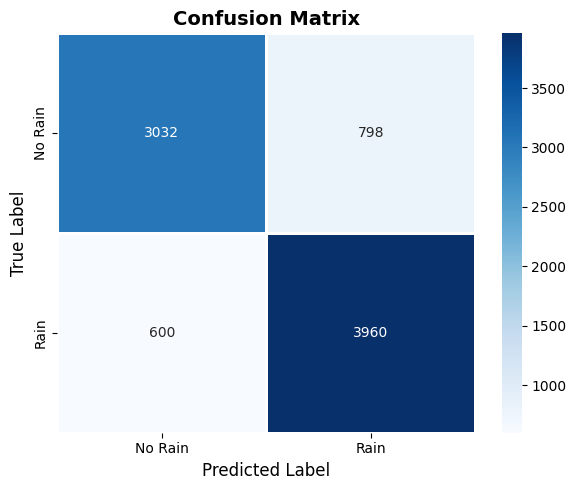

True Negatives  (No Rain predicted correctly): 3032
False Positives (Rain missed — said No Rain) : 798
False Negatives (No Rain — said Rain)        : 600
True Positives  (Rain predicted correctly)   : 3960


In [16]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Rain', 'Rain'],
    yticklabels=['No Rain', 'Rain'],
    ax=ax, linewidths=1, linecolor='white'
)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f'True Negatives  (No Rain predicted correctly): {TN}')
print(f'False Positives (Rain missed — said No Rain) : {FP}')
print(f'False Negatives (No Rain — said Rain)        : {FN}')
print(f'True Positives  (Rain predicted correctly)   : {TP}')

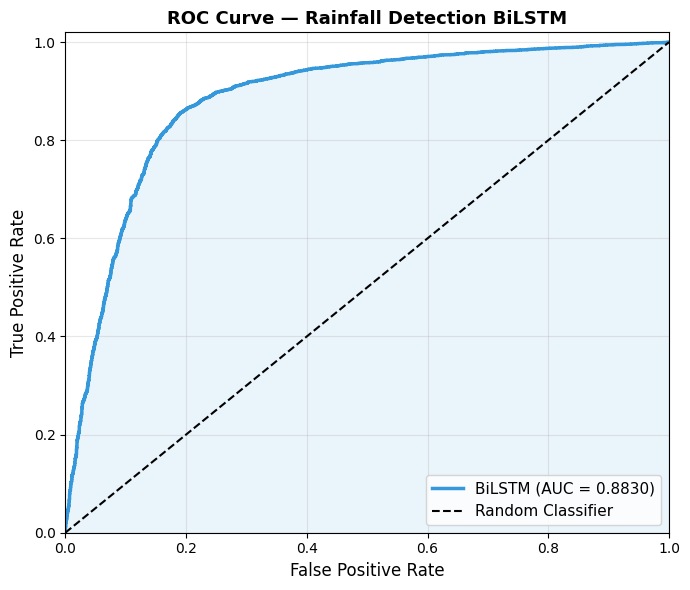

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#3498db', lw=2.5,
        label=f'BiLSTM (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — Rainfall Detection BiLSTM', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

✅ Optimal threshold : 0.36
   Best F1-Score     : 0.8517

🔍 Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

     No Rain       0.86      0.75      0.80      3830
        Rain       0.81      0.90      0.85      4560

    accuracy                           0.83      8390
   macro avg       0.84      0.82      0.83      8390
weighted avg       0.83      0.83      0.83      8390



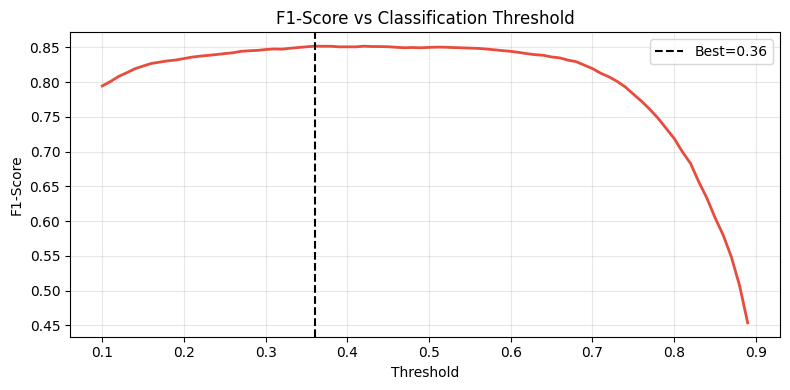

In [18]:
# Find threshold that maximises F1-Score
thresholds_range = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds_range]

best_thresh = thresholds_range[np.argmax(f1_scores)]
best_f1     = max(f1_scores)

print(f'✅ Optimal threshold : {best_thresh:.2f}')
print(f'   Best F1-Score     : {best_f1:.4f}')

# Apply best threshold
y_pred_best = (y_prob >= best_thresh).astype(int)
print('\n🔍 Classification Report with Optimal Threshold:')
print(classification_report(y_test, y_pred_best, target_names=['No Rain', 'Rain']))

# Plot F1 vs Threshold
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds_range, f1_scores, color='#e74c3c', lw=2)
ax.axvline(best_thresh, color='black', linestyle='--', label=f'Best={best_thresh:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score vs Classification Threshold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
def predict_rainfall(model, scaler, recent_data, lookback=24, threshold=0.5):
    """
    Predict rainfall from recent hourly weather data.

    recent_data : DataFrame with same feature columns used in training
                  (must have at least `lookback` rows)
    """
    assert len(recent_data) >= lookback, f'Need at least {lookback} rows'

    # Take last `lookback` hours
    window  = recent_data.iloc[-lookback:][ALL_FEATURES].values
    scaled  = scaler.transform(window)
    seq     = scaled.reshape(1, lookback, -1)

    prob = model.predict(seq, verbose=0)[0][0]
    label = 'RAIN 🌧️' if prob >= threshold else 'NO RAIN ☀️'

    print(f'Prediction  : {label}')
    print(f'Probability : {prob:.4f} ({prob*100:.1f}%)')
    return prob

# ── Demo on last window from test set ────────────────────────────────
sample_df = df_clean.iloc[-50:]
print('=== Single Prediction Demo ===')
predict_rainfall(model, scaler, sample_df, lookback=LOOKBACK, threshold=best_thresh)

=== Single Prediction Demo ===
Prediction  : NO RAIN ☀️
Probability : 0.0203 (2.0%)


np.float32(0.020333147)

In [20]:
import joblib

# Save model
model.save('rainfall_bilstm_final.h5')

# Save scaler
joblib.dump(scaler, 'rainfall_scaler.pkl')

# Save feature list
joblib.dump(ALL_FEATURES, 'rainfall_features.pkl')

print('✅ Model saved as  : rainfall_bilstm_final.h5')
print('✅ Scaler saved as : rainfall_scaler.pkl')
print('✅ Features saved  : rainfall_features.pkl')
print('\n📌 To reload:')
print("  model  = tf.keras.models.load_model('rainfall_bilstm_final.h5')")
print("  scaler = joblib.load('rainfall_scaler.pkl')")

✅ Model saved as  : rainfall_bilstm_final.h5
✅ Scaler saved as : rainfall_scaler.pkl
✅ Features saved  : rainfall_features.pkl

📌 To reload:
  model  = tf.keras.models.load_model('rainfall_bilstm_final.h5')
  scaler = joblib.load('rainfall_scaler.pkl')


In [21]:
print('=' * 50)
print('     🌧️ RAINFALL DETECTION — FINAL SUMMARY')
print('=' * 50)
print(f'  Model           : Bidirectional LSTM (3 layers)')
print(f'  Dataset         : Historical Hourly Weather')
print(f'  City            : {CITY}')
print(f'  Lookback Window : {LOOKBACK} hours')
print(f'  Total Features  : {len(ALL_FEATURES)}')
print(f'  Train Samples   : {X_train.shape[0]:,}')
print(f'  Test Samples    : {X_test.shape[0]:,}')
print('-' * 50)
print(f'  Test Accuracy   : {acc*100:.2f}%')
print(f'  F1-Score        : {best_f1:.4f}')
print(f'  ROC-AUC         : {roc_auc:.4f}')
print(f'  Best Threshold  : {best_thresh:.2f}')
print('=' * 50)

     🌧️ RAINFALL DETECTION — FINAL SUMMARY
  Model           : Bidirectional LSTM (3 layers)
  Dataset         : Historical Hourly Weather
  City            : Vancouver
  Lookback Window : 24 hours
  Total Features  : 22
  Train Samples   : 39,151
  Test Samples    : 8,390
--------------------------------------------------
  Test Accuracy   : 83.34%
  F1-Score        : 0.8517
  ROC-AUC         : 0.8830
  Best Threshold  : 0.36
